In [1]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [ ]:
API_KEY = ""
CLASS_ID = "Tobasum-Testing-Joyner-Data"
SAMPLE_SIZE = None  # Set to a number for testing or None for all data

In [3]:
def get_score_history(user_id, current_timestamp, df_sorted):
    """Get score history for this user up to this point"""
    if df_sorted.empty:
        return []
    
    user_previous = df_sorted[
        (df_sorted['user_id'] == user_id) & 
        (df_sorted['created_at'] < current_timestamp)
    ]
    
    return user_previous['content_score'].tolist() if len(user_previous) > 0 else []

def call_summary_api(summary_text, user_id, timestamp, df_sorted, page_slug, class_id="Tobasum-Testing-Joyner-Data"):
    url = "https://itell-api.learlab.vanderbilt.edu/score/summary"
    
    score_history = get_score_history(user_id, timestamp, df_sorted)
    logger.info(f"Processing user {user_id}, page {page_slug}, score history length: {len(score_history)}")

    payload = {
        "page_slug": page_slug,
        "class_id": class_id,
        "score_history": score_history,
        "summary": summary_text
    }
    headers = {
        "Content-Type": "application/json",
        "API-Key": API_KEY
    }

    try:
        response = requests.post(url, json=payload, headers=headers, timeout=30)
        
        if response.status_code == 200:
            response_dict = response.json()
            response_dict['api_metadata'] = {
                'user_id': user_id,
                'timestamp': timestamp.isoformat() if hasattr(timestamp, 'isoformat') else str(timestamp),
                'page_slug': page_slug,
                'score_history': score_history,
                'status_code': response.status_code,
                'request_payload': payload
            }
            logger.info(f"Successfully processed API call for user {user_id}")
            return response_dict
        else:
            logger.error(f"API call failed for user {user_id}. Status: {response.status_code}")
            return {'error': True, 'status_code': response.status_code}
            
    except Exception as e:
        logger.error(f"Error for user {user_id}: {str(e)}")
        return {'error': True}


In [4]:
def get_score_history(user_id, current_timestamp, df_sorted):
    """Get score history for this user up to this point"""
    if df_sorted.empty:
        return []
    
    user_previous = df_sorted[
        (df_sorted['user_id'] == user_id) & 
        (df_sorted['created_at'] < current_timestamp)
    ]
    
    return user_previous['content_score'].tolist() if len(user_previous) > 0 else []

def call_summary_api(summary_text, user_id, timestamp, df_sorted, page_slug, class_id="Tobasum-Testing-Joyner-Data"):
    url = "https://itell-api.learlab.vanderbilt.edu/score/summary"

    try:
        # Get score history for this user
        score_history = get_score_history(user_id, timestamp, df_sorted)
        logger.info(f"Processing user {user_id}, page {page_slug}, score history length: {len(score_history)}")

        payload = {
            "page_slug": page_slug,
            "class_id": class_id,
            "score_history": score_history,
            "summary": summary_text
        }
        headers = {
            "Content-Type": "application/json",
            "API-Key": API_KEY
        }

        response = requests.request("POST", url, json=payload, headers=headers, timeout=30)
        
        # Check if request was successful
        if response.status_code == 200:
            response_dict = response.json()
            # Add metadata to the response for tracking
            response_dict['api_metadata'] = {
                'user_id': user_id,
                'timestamp': timestamp.isoformat() if hasattr(timestamp, 'isoformat') else str(timestamp),
                'page_slug': page_slug,
                'score_history': score_history,
                'status_code': response.status_code,
                'request_payload': payload
            }
            logger.info(f"Successfully processed API call for user {user_id}")
            return response_dict
        else:
            logger.error(f"API call failed for user {user_id}. Status: {response.status_code}")
            return {'error': True, 'status_code': response.status_code}
            
    except Exception as e:
        logger.error(f"Error for user {user_id}: {str(e)}")
        return {'error': True}

In [5]:
# Load the data from server
df = pd.read_csv("summaries.csv")

# Display basic info about the data
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Unique users: {df['user_id'].nunique()}")
print(f"Date range: {df['created_at'].min()} to {df['created_at'].max()}")

# Show sample data
display(df.head())

# Prepare data for API calls
required_cols = ['user_id', 'text', 'created_at'] 
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f"Missing columns: {missing_cols}")
    print("Available columns: {list(df.columns)}")
else:
    print("All required columns present")
    
# Sort by timestamp
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at')
print(f"Rows after sorting: {len(df)}")

Total rows: 994
Columns: ['id', 'text', 'condition', 'user_id', 'page_slug', 'is_passed', 'containment_score', 'similarity_score', 'content_score', 'content_threshold', 'is_excellent', 'created_at', 'updated_at']
Unique users: 127
Date range: 2025-06-02T15:40:05.637001+00:00 to 2025-07-21T19:10:20.558299+00:00


,id,text,condition,user_id,page_slug,is_passed,containment_score,similarity_score,content_score,content_threshold,is_excellent,created_at,updated_at
0,60,Thi spage talks about how contril stuctues are...,random_reread,226ajlpobyjbksx534h6rrg2jq,3-1-control-structures,True,0.0000,0.736030,0.170597,0.004953,True,2025-06-02T15:40:05.637001+00:00,2025-06-02T15:40:05.637001+00:00
1,61,"In this chapter of the unit 3 lessons, the art...",random_reread,226ajlpobyjbksx534h6rrg2jq,3-2-conditionals,True,0.0000,0.520184,0.077714,0.004953,True,2025-06-02T17:31:34.022806+00:00,2025-06-02T17:31:34.022806+00:00
2,62,"In this section of the lesson for unit 3, the ...",random_reread,226ajlpobyjbksx534h6rrg2jq,3-3-loops,True,0.0000,0.779228,0.349814,0.004953,True,2025-06-02T17:36:51.540634+00:00,2025-06-02T17:36:51.540634+00:00
3,63,"In this chapter of unit 3, the article talks a...",random_reread,226ajlpobyjbksx534h6rrg2jq,3-4-functions,True,0.0000,0.758652,0.611322,0.004953,True,2025-06-02T17:41:39.63132+00:00,2025-06-02T17:41:39.63132+00:00
4,64,"In this article for unit 3, the article talks ...",random_reread,226ajlpobyjbksx534h6rrg2jq,3-5-error-handling,True,0.1053,0.785503,0.431579,0.004953,True,2025-06-02T17:50:59.201884+00:00,2025-06-02T17:50:59.201884+00:00


All required columns present
Rows after sorting: 994


In [6]:
# Test API connection and class availability

def test_api_connection():
    """Test API connection with a simple request"""
    test_response = call_summary_api(
        summary_text="This is a test summary to check API connectivity.",
        user_id="test_user_123",
        timestamp=pd.Timestamp.now(),
        df_sorted=pd.DataFrame(),
        page_slug="test-page",
        class_id=CLASS_ID
    )
    
    if test_response.get('error'):
        print(f"API Test Failed: Status {test_response.get('status_code', 'Unknown')}")
        return False
    else:
        print("API Test Successful!")
        print(f"Response contains: {list(test_response.keys())}")
        return True

test_api_connection()

2025-08-29 19:06:19,105 - INFO - Processing user test_user_123, page test-page, score history length: 0
2025-08-29 19:06:21,804 - INFO - Successfully processed API call for user test_user_123


API Test Successful!
Response contains: ['is_passed', 'prompt', 'metrics', 'api_metadata']


True

In [8]:
# Sample data if needed - keep original df for full historical context
df_full = df.copy()  # Keep the full dataset for score history lookup

if SAMPLE_SIZE is not None:
    df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42)
    print(f"Testing with {len(df_sample)} sampled entries")
    print(f"Using full dataset ({len(df_full)} entries) for historical context")
else:
    df_sample = df.copy()
    print(f"Testing with all {len(df)} entries")

Testing with all 994 entries


In [9]:
print("Making API calls...")
logger.info(f"Starting API calls for {len(df_sample)} submissions")

all_responses = []

for i, row in enumerate(df_sample.itertuples()):
    # print(f"Processing summary {i+1}/{len(df_sample)} for user {row.user_id}")
    
    summary_text = row.text
    user_id = row.user_id
    timestamp = row.created_at
    
    # Call API with full historical context for this user
    response = call_summary_api(summary_text, user_id, timestamp, df_full, row.page_slug, CLASS_ID)
    
    if response:
        all_responses.append(response)
    
    # Small delay
    import time
    time.sleep(0.1)

print(f"Completed {len(all_responses)} API calls")

# Save to JSONL file
output_filename = "summary_scores.jsonl"
with open(output_filename, "w") as f:
    for response in all_responses:
        f.write(json.dumps(response) + "\n")

print(f"Saved API responses to {output_filename}")
logger.info(f"Saved {len(all_responses)} responses to {output_filename}")

2025-08-29 19:07:04,965 - INFO - Starting API calls for 994 submissions
2025-08-29 19:07:04,972 - INFO - Processing user 226ajlpobyjbksx534h6rrg2jq, page 3-1-control-structures, score history length: 0


Making API calls...


2025-08-29 19:07:07,786 - INFO - Successfully processed API call for user 226ajlpobyjbksx534h6rrg2jq
2025-08-29 19:07:07,894 - INFO - Processing user 226ajlpobyjbksx534h6rrg2jq, page 3-2-conditionals, score history length: 1
2025-08-29 19:07:10,751 - INFO - Successfully processed API call for user 226ajlpobyjbksx534h6rrg2jq
2025-08-29 19:07:10,859 - INFO - Processing user 226ajlpobyjbksx534h6rrg2jq, page 3-3-loops, score history length: 2
2025-08-29 19:07:13,775 - INFO - Successfully processed API call for user 226ajlpobyjbksx534h6rrg2jq
2025-08-29 19:07:13,884 - INFO - Processing user 226ajlpobyjbksx534h6rrg2jq, page 3-4-functions, score history length: 3
2025-08-29 19:07:16,887 - INFO - Successfully processed API call for user 226ajlpobyjbksx534h6rrg2jq
2025-08-29 19:07:16,994 - INFO - Processing user 226ajlpobyjbksx534h6rrg2jq, page 3-5-error-handling, score history length: 4
2025-08-29 19:07:19,937 - INFO - Successfully processed API call for user 226ajlpobyjbksx534h6rrg2jq
2025-08

Completed 994 API calls
Saved API responses to summary_scores.jsonl


In [10]:
# Load and process API responses (simplified)
with open("summary_scores.jsonl", "r") as f:
    responses = [json.loads(line) for line in f]

print(f"Loaded {len(responses)} responses")

# Filter successful responses and extract metrics
successful_responses = [r for r in responses if not r.get('error', False)]
print(f"Found {len(successful_responses)} successful responses")

metrics_list = []
for response in successful_responses:
    metric_data = response['metrics'].copy()
    metadata = response['api_metadata']
    metric_data.update({
        'user_id': metadata['user_id'],
        'timestamp': metadata['timestamp'],
        'page_slug': metadata['page_slug'],
        'score_history': metadata.get('score_history', []),
        'score_history_length': len(metadata.get('score_history', []))
    })
    metrics_list.append(metric_data)

# Create DataFrame and extract key metrics
global df_metrics
df_metrics = pd.DataFrame(metrics_list)

# Convert timestamp and sort by time
df_metrics['timestamp'] = pd.to_datetime(df_metrics['timestamp'])
df_metrics = df_metrics.sort_values('timestamp').reset_index(drop=True)

# Extract content scores and thresholds from nested structure
df_metrics['content_score'] = [row['content']['score'] for _, row in df_metrics.iterrows()]
df_metrics['api_threshold'] = [row['content']['threshold'] for _, row in df_metrics.iterrows()]

print(f"Processed {len(df_metrics)} responses with metrics")
display(df_metrics[['user_id', 'content_score', 'api_threshold', 'score_history_length']].sample(min(3, len(df_metrics))))


Loaded 994 responses
Found 961 successful responses
Processed 961 responses with metrics


,user_id,content_score,api_threshold,score_history_length
786,ojedcggygcymjf4wwdqze6o3re,NaN,0.000000,8
110,ltpnzwsggnrat3o5ci6cufle2u,0.123430,0.257848,2
529,gkbufdjek2ljjzga2kinbozd7i,0.356565,0.383062,3


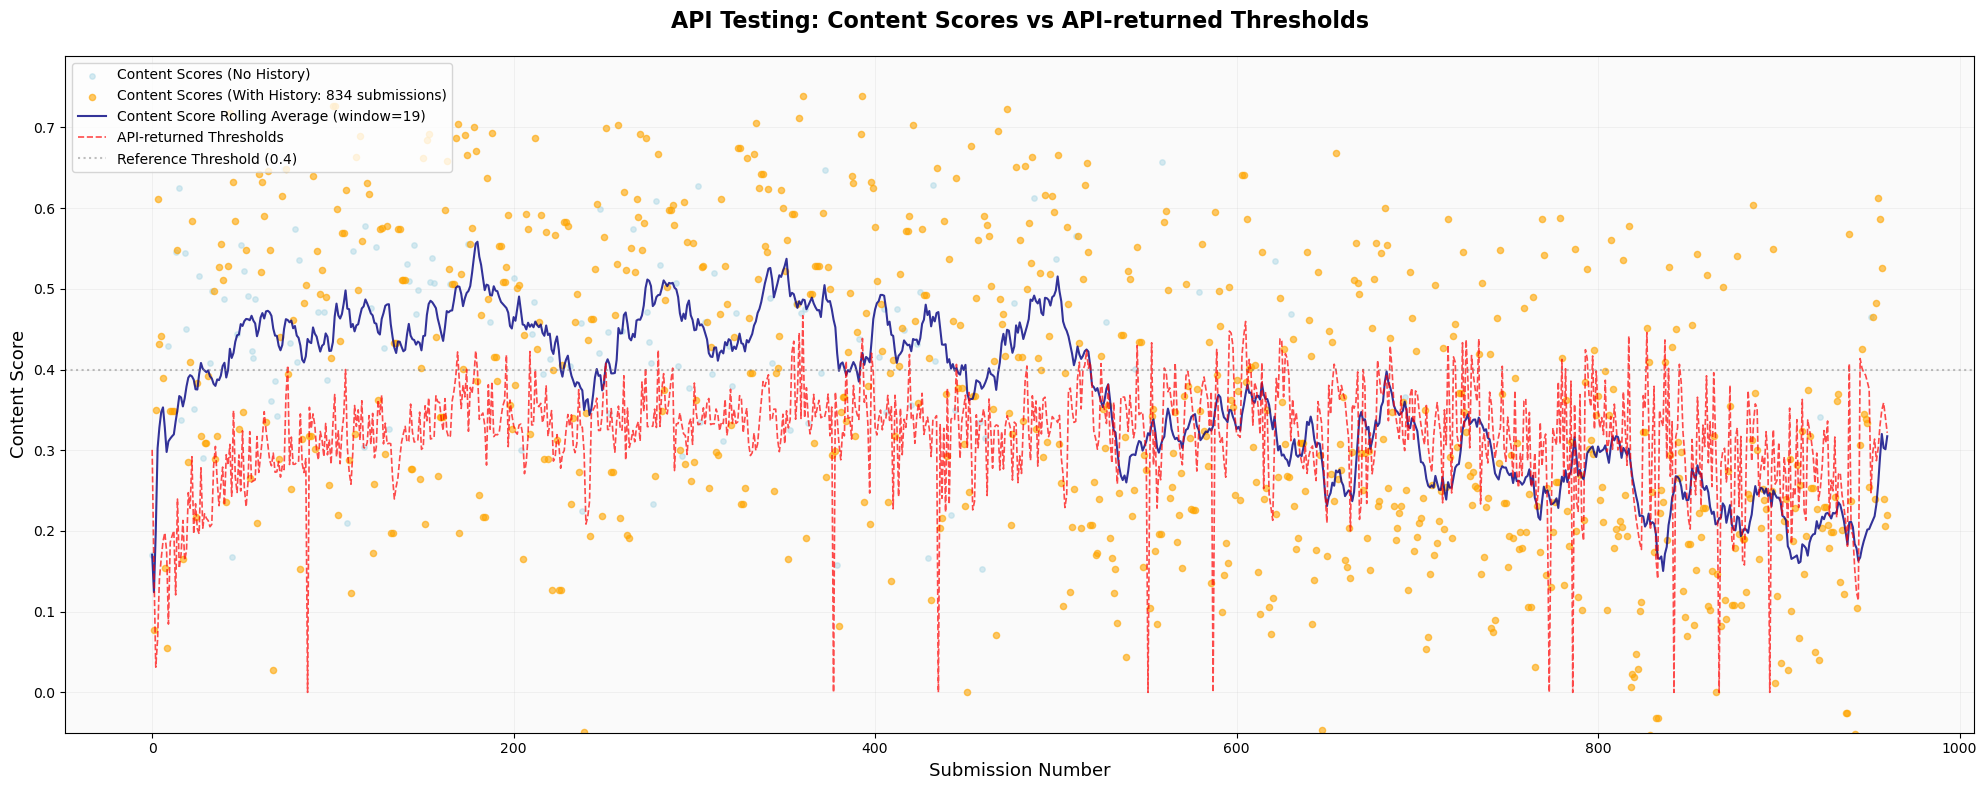

Total submissions tested: 961


In [ ]:
# Visualization
if 'df_metrics' in globals() and len(df_metrics) > 0:
    plt.style.use('default')
    fig, ax = plt.subplots(1, figsize=(20, 8))
    
    window_size = max(10, len(df_metrics) // 50) 
    rolling_avg = df_metrics['content_score'].rolling(window=window_size, min_periods=1).mean()
    
    no_history = df_metrics[df_metrics['score_history_length'] == 0]
    with_history = df_metrics[df_metrics['score_history_length'] > 0]
    
    if len(no_history) > 0:
        ax.scatter(no_history.index, no_history['content_score'], 
                   color='lightblue', alpha=0.5, s=15, label='Content Scores (No History)')
    
    if len(with_history) > 0:
        ax.scatter(with_history.index, with_history['content_score'],
                   color='orange', alpha=0.6, s=20, marker='o',
                   label=f'Content Scores (With History: {len(with_history)} submissions)')

    ax.plot(df_metrics.index, rolling_avg, 
            color='navy', linewidth=1.5, alpha=0.8, 
            label=f'Content Score Rolling Average (window={window_size})')

    ax.plot(df_metrics.index, df_metrics['api_threshold'], 
            color='red', linewidth=1.2, linestyle='--', alpha=0.7,
            label='API-returned Thresholds')
    
    ax.axhline(y=0.4, color='gray', linestyle=':', alpha=0.5, label='Reference Threshold (0.4)')
   
    ax.set_title('API Testing: Content Scores vs API-returned Thresholds', fontsize=16, pad=20, fontweight='bold')
    ax.set_xlabel('Submission Number', fontsize=13)
    ax.set_ylabel('Content Score', fontsize=13)
    ax.set_ylim(-0.05, max(df_metrics['content_score'].max(), df_metrics['api_threshold'].max()) + 0.05)
   
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
    ax.set_facecolor('#fafafa')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total submissions tested: {len(df_metrics)}")